# Analisis Backtest Strategi Multi-Timeframe (MTF) Long-Only
## 1D Macro-Trend Filter + 1H Micro-Entry Trigger

**Notebook Riset Kuantitatif — Tugas Akhir (Skripsi)**

---

Notebook ini mengimplementasikan sistem trading deterministik MTF berbasis **Dynamic Trailing Stop Long-Only**
(menggunakan EMA 1D untuk melihat tren besar, dan RSI/MACD 1H untuk eksekusi presisi)
pada data S&P 500, NASDAQ 100, dan Dow Jones.

In [ ]:
# =============================================================================
# SEL 1: FUNGSI PREPROCESSING & INDIKATOR MTF
# =============================================================================
import pandas as pd
import numpy as np

def load_data(filepath):
    if filepath.endswith('.parquet'):
        df = pd.read_parquet(filepath)
        df['datetime'] = pd.to_datetime(df['datetime'])
    else:
        df = pd.read_csv(filepath, sep='\t')
        col_name = 'DateTime' if 'DateTime' in df.columns else 'datetime'
        df['datetime_parsed'] = pd.to_datetime(df[col_name].str.replace('.', '-'), format='mixed', dayfirst=False)
        df.drop(columns=[col_name], inplace=True)
        df.rename(columns={'datetime_parsed': 'datetime'}, inplace=True)
    
    df.sort_values('datetime', inplace=True)
    df.drop_duplicates('datetime', inplace=True)
    df.rename(columns={'Open':'open', 'High':'high', 'Low':'low', 'Close':'close', 'Volume':'volume'}, inplace=True)
    df.columns = [c.lower() for c in df.columns]
    # Hapus kolom duplikat jika masih ada
    df = df.loc[:, ~df.columns.duplicated()]
    return df

def calc_ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def calc_macd(series, fast=12, slow=26, signal=9):
    ema_fast = calc_ema(series, fast)
    ema_slow = calc_ema(series, slow)
    macd_line = ema_fast - ema_slow
    macd_signal = calc_ema(macd_line, signal)
    return macd_line, macd_signal

def calc_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).ewm(alpha=1/period, adjust=False).mean()
    loss = (-delta.where(delta < 0, 0)).ewm(alpha=1/period, adjust=False).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def siapkan_data_mtf(f_1d, f_1h):
    df_1d = load_data(f_1d)
    df_1h = load_data(f_1h)
    
    # Terapkan Shift(1) agar data harian tidak mengandung lookahead bias!
    df_1d['ema_50_1d'] = calc_ema(df_1d['close'], 50).shift(1)
    df_1d['ema_100_1d'] = calc_ema(df_1d['close'], 100).shift(1)
    df_1d['ema_200_1d'] = calc_ema(df_1d['close'], 200).shift(1)
    df_1d['date'] = df_1d['datetime'].dt.date
    df_1d.drop_duplicates('date', keep='last', inplace=True)
    
    df_1h['date'] = df_1h['datetime'].dt.date
    
    # Gabungkan data 1D ke 1H
    df_merged = pd.merge(df_1h, df_1d[['date', 'ema_50_1d', 'ema_100_1d', 'ema_200_1d']], on='date', how='left')
    df_merged.ffill(inplace=True)
    df_merged.dropna(inplace=True)
    df_merged.reset_index(drop=True, inplace=True)
    
    # Indikator 1H Intraday
    df_merged['macd_line'], df_merged['macd_signal'] = calc_macd(df_merged['close'])
    df_merged['rsi'] = calc_rsi(df_merged['close'])
    df_merged.fillna(0, inplace=True)
    
    return df_merged

print("[OK] Modul fungsi data berhasil dimuat.")

[OK] Modul fungsi data berhasil dimuat.


In [2]:
# =============================================================================
# SEL 2: MEMUAT ALIGNMENT DATA MTF UNTUK SELURUH INSTRUMEN
# =============================================================================
print("Memproses data Multi-Timeframe...")
d_files = {
    'SPY': ('data/spy_US500_D1.parquet', 'data/spy_US500_H1.parquet'),
    'NDX': ('data/Nasdaq100_1d_data.csv', 'data/Nasdaq100_1h_data.csv'),
    'DJI': ('data/Dow_Jones_1d_data.csv', 'data/Dow_Jones_1h_data.csv')
}

df_spy = siapkan_data_mtf(*d_files['SPY'])
print(f"  S&P 500 (SPY): {len(df_spy)} bar tersinkronisasi.")

df_ndx = siapkan_data_mtf(*d_files['NDX'])
print(f"  NASDAQ 100: {len(df_ndx)} bar tersinkronisasi.")

df_dji = siapkan_data_mtf(*d_files['DJI'])
print(f"  Dow Jones (DJI): {len(df_dji)} bar tersinkronisasi.")

print("\n[OK] Data 1D dan 1H berhasil digabungkan tanpa lookahead bias.")

Memproses data Multi-Timeframe...
  S&P 500 (SPY): 50172 bar tersinkronisasi.
  NASDAQ 100: 51871 bar tersinkronisasi.
  Dow Jones (DJI): 49303 bar tersinkronisasi.

[OK] Data 1D dan 1H berhasil digabungkan tanpa lookahead bias.


In [3]:
# =============================================================================
# SEL 3: MESIN STRATEGI MTF & TRAILING STOP
# =============================================================================
def simulasi_strategi_mtf(df_merged, nama_instrumen, biaya=0.0002):

    if isinstance(df_merged.index, pd.DatetimeIndex):
        start_date = df_merged.index[0].strftime('%Y-%m-%d %H:%M')
        end_date = df_merged.index[-1].strftime('%Y-%m-%d %H:%M')
    elif 'datetime' in df_merged.columns:
        start_date = pd.to_datetime(df_merged['datetime'].iloc[0]).strftime('%Y-%m-%d %H:%M')
        end_date = pd.to_datetime(df_merged['datetime'].iloc[-1]).strftime('%Y-%m-%d %H:%M')
    else:
        start_date = str(df_merged.index[0])
        end_date = str(df_merged.index[-1])
    jumlah_bar_setelah_dropna = len(df_merged)
    bh_return_direct = (df_merged['close'].iloc[-1] / df_merged['close'].iloc[0]) - 1
    close_p = df_merged['close'].values
    high_p = df_merged['high'].values if 'high' in df_merged.columns else close_p
    low_p = df_merged['low'].values if 'low' in df_merged.columns else close_p
    
    ema_50_1d = df_merged['ema_50_1d'].values
    ema_100_1d = df_merged['ema_100_1d'].values
    ema_200_1d = df_merged['ema_200_1d'].values
    
    macd_line = df_merged['macd_line'].values
    macd_signal = df_merged['macd_signal'].values
    rsi = df_merged['rsi'].values
    
    p_state = np.zeros(len(df_merged))
    ret_strat = np.zeros(len(df_merged))
    trade_exec = np.zeros(len(df_merged))
    
    trailing_dist = 0.025
    extreme_tp = 0.05
    
    posisi = 0.0
    highest_price = 0.0
    sl_price = 0.0
    tp_price = 0.0
    
    rsi_cross = (pd.Series(rsi).shift(1) <= 50) & (pd.Series(rsi) > 50)
    rsi_cross = rsi_cross.values

    for i in range(1, len(df_merged)):
        if posisi == 0.0:
            if rsi_cross[i]:
                tren = (ema_50_1d[i] > ema_100_1d[i]) and (ema_100_1d[i] > ema_200_1d[i])
                mom = macd_line[i] > macd_signal[i]
                
                if tren and mom:
                    posisi = 1.0
                    entry_price = close_p[i]
                    highest_price = entry_price
                    sl_price = entry_price * (1 - trailing_dist)
                    tp_price = entry_price * (1 + extreme_tp)
                    
                    p_state[i] = 1.0
                    trade_exec[i] = 1.0
        elif posisi == 1.0:
            hit_tp = high_p[i] >= tp_price
            hit_sl = low_p[i] <= sl_price
            
            if hit_tp or hit_sl:
                posisi = 0.0
                p_state[i] = 0.0
                trade_exec[i] += 1.0
                exit_price = sl_price if hit_sl else tp_price
                ret_strat[i] = (exit_price / close_p[i-1]) - 1.0
            else:
                p_state[i] = 1.0
                ret_strat[i] = (close_p[i] / close_p[i-1]) - 1.0
                if high_p[i] > highest_price:
                    highest_price = high_p[i]
                    sl_price = max(sl_price, highest_price * (1 - trailing_dist))

    return_strategi = pd.Series(ret_strat, index=df_merged.index) - (pd.Series(trade_exec, index=df_merged.index) * biaya)
    return_strategi = return_strategi.fillna(0)
    
    return_kumulatif = (1 + return_strategi).cumprod()
    return_pasar = df_merged['close'].pct_change().fillna(0)
    return_bnh = (1 + return_pasar).cumprod()
    
    peak_kumulatif = return_kumulatif.cummax()
    drawdown = (return_kumulatif - peak_kumulatif) / peak_kumulatif
    
    df_merged['posisi'] = p_state
    
    # === LOG TRANSAKSI ===
    perubahan = pd.Series(trade_exec, index=df_merged.index)
    mask_transaksi = perubahan != 0
    log = df_merged.loc[mask_transaksi, ['datetime', 'close', 'rsi', 'posisi']].copy()
    perubahan_log = perubahan[mask_transaksi].values
    posisi_log = log['posisi'].values
    log['aksi'] = np.where(perubahan_log > 1, 'BUY & SELL', np.where((perubahan_log == 1) & (posisi_log == 1), 'LONG ENTRY', 'EXIT (TS/TP)'))
    log.set_index('datetime', inplace=True)
    
    print(f"  [{nama_instrumen}] Strategi selesai — Total transaksi/sinyal: {mask_transaksi.sum()}, Return akhir: {return_kumulatif.iloc[-1]:.4f}x")
    
    return {
        'nama': nama_instrumen,
        'return_strategi': return_strategi,
        'return_kumulatif': return_kumulatif,
        'return_bnh': return_bnh,
        'drawdown': drawdown,
        'log_transaksi': log,
        'posisi': df_merged['posisi'],
        'df_len': len(df_merged), 'start_date': start_date, 'end_date': end_date, 'total_bars': jumlah_bar_setelah_dropna, 'bh_return_direct': bh_return_direct
    }

print("Menjalankan simulasi strategi kuantitatif MTF (1D Trend + 1H Trigger)...\n")
hasil_spy = simulasi_strategi_mtf(df_spy, 'S&P 500 (SPY)')
hasil_ndx = simulasi_strategi_mtf(df_ndx, 'NASDAQ 100')
hasil_dji = simulasi_strategi_mtf(df_dji, 'Dow Jones (DJI)')

daftar_hasil = [hasil_spy, hasil_ndx, hasil_dji]
print("\n" + "="*60)




Menjalankan simulasi strategi kuantitatif MTF (1D Trend + 1H Trigger)...

  [S&P 500 (SPY)] Strategi selesai — Total transaksi/sinyal: 361, Return akhir: 1.0680x
  [NASDAQ 100] Strategi selesai — Total transaksi/sinyal: 503, Return akhir: 2.5417x
  [Dow Jones (DJI)] Strategi selesai — Total transaksi/sinyal: 269, Return akhir: 1.5082x



In [4]:
# =============================================================================
# SEL 6: TABEL EVALUASI KINERJA (PERFORMANCE METRICS TABLE)
# =============================================================================
import pandas as pd
import numpy as np

BARS_PER_TAHUN = 252 * 24

def hitung_metrik(hasil, bars_per_tahun=BARS_PER_TAHUN):
    ret = hasil['return_strategi']
    cum = hasil['return_kumulatif']
    dd = hasil['drawdown']
    posisi = hasil['posisi']
    
    total_return = cum.iloc[-1] - 1
    total_bars = len(ret)
    total_tahun = total_bars / bars_per_tahun
    cagr = (cum.iloc[-1] ** (1 / total_tahun)) - 1 if total_tahun > 0 else 0
    vol_tahunan = ret.std() * np.sqrt(bars_per_tahun)
    sharpe = (ret.mean() / ret.std()) * np.sqrt(bars_per_tahun) if ret.std() > 0 else 0
    
    downside_ret = ret[ret < 0]
    downside_std = downside_ret.std() if len(downside_ret) > 0 else 0
    sortino = (ret.mean() / downside_std) * np.sqrt(bars_per_tahun) if downside_std > 0 else 0
    max_drawdown = dd.min()
    
    perubahan = posisi.diff().fillna(posisi)
    idx_perubahan = perubahan[perubahan != 0].index
    trade_returns = []
    i = 0
    while i < len(idx_perubahan):
        pos_val = posisi.loc[idx_perubahan[i]]
        if pos_val != 0:
            start = idx_perubahan[i]
            exit_found = False
            for j in range(i + 1, len(idx_perubahan)):
                if posisi.loc[idx_perubahan[j]] == 0:
                    end = idx_perubahan[j]
                    trade_ret = ret.loc[start:end]
                    trade_cum = (1 + trade_ret).prod() - 1
                    trade_returns.append(trade_cum)
                    i = j + 1
                    exit_found = True
                    break
            if not exit_found:
                trade_ret = ret.loc[start:]
                trade_cum = (1 + trade_ret).prod() - 1
                trade_returns.append(trade_cum)
                break
        else:
            i += 1
            
    trade_returns = np.array(trade_returns)
    total_trades = len(trade_returns)
    winning = trade_returns[trade_returns > 0]
    win_rate = len(winning) / total_trades * 100 if total_trades > 0 else 0
    gross_profit = winning.sum() if len(winning) > 0 else 0
    losing = trade_returns[trade_returns < 0]
    gross_loss = abs(losing.sum()) if len(losing) > 0 else 1e-10
    profit_factor = gross_profit / gross_loss
    
    res_strat = {
        'Instrumen': f"{hasil['nama']} (Strat)",
        'Total Return (%)': total_return * 100,
        'CAGR (%)': cagr * 100,
        'Ann Volatility (%)': vol_tahunan * 100,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown (%)': max_drawdown * 100,
        'Win Rate (%)': win_rate,
        'Profit Factor': profit_factor,
        'Total Trades': total_trades
    }
    
    cum_bnh = hasil['return_bnh']
    ret_bnh = cum_bnh.pct_change().fillna(0)
    
    total_return_b = hasil.get('bh_return_direct', cum_bnh.iloc[-1] - 1)
    cagr_b = ((1 + total_return_b) ** (1 / total_tahun)) - 1 if total_tahun > 0 else 0
    vol_tahunan_b = ret_bnh.std() * np.sqrt(bars_per_tahun)
    sharpe_b = (ret_bnh.mean() / ret_bnh.std()) * np.sqrt(bars_per_tahun) if ret_bnh.std() > 0 else 0
    
    downside_ret_b = ret_bnh[ret_bnh < 0]
    downside_std_b = downside_ret_b.std() if len(downside_ret_b) > 0 else 0
    sortino_b = (ret_bnh.mean() / downside_std_b) * np.sqrt(bars_per_tahun) if downside_std_b > 0 else 0
    
    peak_b = cum_bnh.cummax()
    dd_b = (cum_bnh - peak_b) / peak_b
    max_drawdown_b = dd_b.min()
    
    winning_b = ret_bnh[ret_bnh > 0]
    win_rate_b = len(winning_b) / len(ret_bnh) * 100 if len(ret_bnh) > 0 else 0
    gross_profit_b = winning_b.sum() if len(winning_b) > 0 else 0
    losing_b = ret_bnh[ret_bnh < 0]
    gross_loss_b = abs(losing_b.sum()) if len(losing_b) > 0 else 1e-10
    profit_factor_b = gross_profit_b / gross_loss_b
    
    res_bnh = {
        'Instrumen': f"{hasil['nama']} (B&H)",
        'Total Return (%)': total_return_b * 100,
        'CAGR (%)': cagr_b * 100,
        'Ann Volatility (%)': vol_tahunan_b * 100,
        'Sharpe Ratio': sharpe_b,
        'Sortino Ratio': sortino_b,
        'Max Drawdown (%)': max_drawdown_b * 100,
        'Win Rate (%)': win_rate_b,
        'Profit Factor': profit_factor_b,
        'Total Trades': 1
    }
    
    return [res_strat, res_bnh]

def print_evaluation_table(daftar_hasil, model_name, phase_name):
    metrik_list = []
    for h in daftar_hasil:
        metrik_list.extend(hitung_metrik(h))
    df_metrik = pd.DataFrame(metrik_list).set_index('Instrumen')

    pd.set_option('display.float_format', lambda x: '%.4f' % x)
    pd.set_option('display.width', 1000)

    start_date = daftar_hasil[0]['start_date']
    end_date = daftar_hasil[0]['end_date']
    total_bars = daftar_hasil[0]['total_bars']

    print("================================================================================")
    print(f"[{model_name}] - [{phase_name}]")
    print(f"EVALUATION PERIOD : {start_date} to {end_date}")
    print(f"TOTAL BARS TESTED : {total_bars}")
    print("================================================================================")
    print(df_metrik.to_string())
    print()

def print_trade_logs(daftar_hasil):
    print("================================================================================")
    print("[RECENT TRADE LOGS] LAST 5 EXECUTIONS")
    print("================================================================================")
    for h in daftar_hasil:
        log = h['log_transaksi']
        print(f"\n--- {h['nama']} ---")
        if len(log) > 0:
            tampilan = log.tail(5)[['close', 'rsi', 'posisi', 'aksi']].copy()
            tampilan.columns = ['Close', 'RSI(14)', 'Posisi', 'Aksi']
            print(tampilan.to_string())
        else:
            print("  Tidak ada transaksi tercatat.")
    print("\n" + "=" * 80)

# Cetak In-Sample
print_evaluation_table(daftar_hasil, "MULTI-TIMEFRAME (1D+1H)", "IN-SAMPLE BACKTEST")


[MULTI-TIMEFRAME (1D+1H)] - [IN-SAMPLE BACKTEST]
EVALUATION PERIOD : 2018-02-19 16:00 to 2026-08-19 11:00
TOTAL BARS TESTED : 50172
                         Total Return (%)  CAGR (%)  Ann Volatility (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)  Win Rate (%)  Profit Factor  Total Trades
Instrumen                                                                                                                                                        
S&P 500 (SPY) (Strat)              6.8021    0.7964             10.4409        0.1282         0.1177          -23.3231       34.2541         1.0701           181
S&P 500 (SPY) (B&H)              181.8132   13.3028             19.2060        0.7463         0.8592          -35.6741       51.4809         1.0347             1
NASDAQ 100 (Strat)               154.1716   11.4902             12.5530        0.9293         0.8357          -15.8812       44.0476         1.4620           252
NASDAQ 100 (B&H)                 415.3545   21.0680       

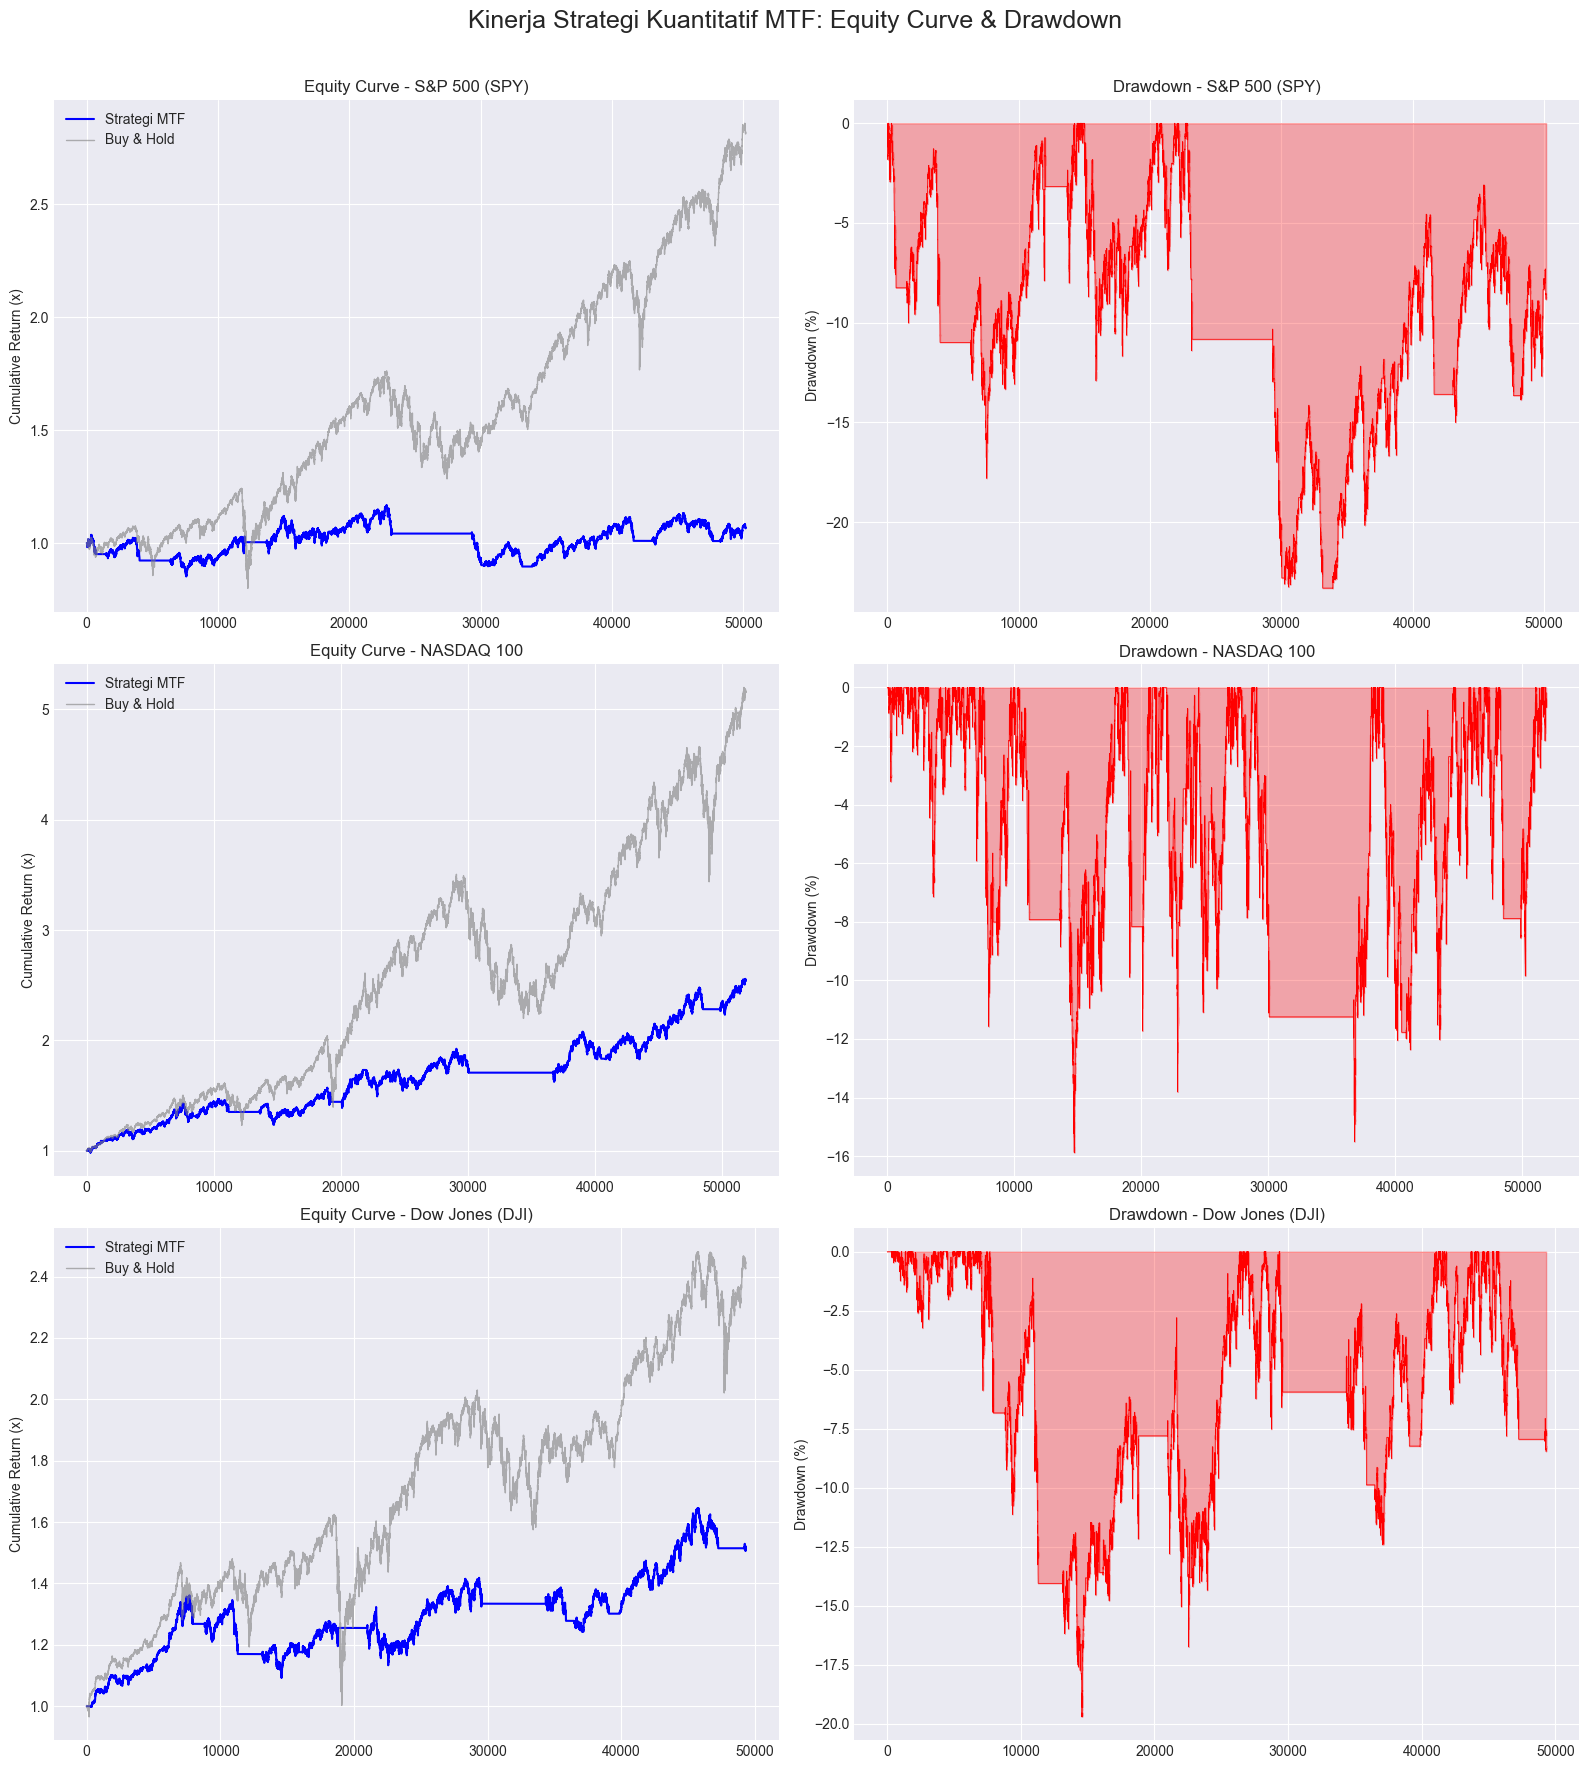

[RECENT TRADE LOGS] LAST 5 EXECUTIONS

--- S&P 500 (SPY) ---
                        Close  RSI(14)  Posisi          Aksi
datetime                                                    
2026-07-24 12:00:00 7429.0000  50.3529  1.0000    LONG ENTRY
2026-07-29 23:00:00 7305.4000  33.7307  0.0000  EXIT (TS/TP)
2026-07-30 14:00:00 7368.1000  50.7459  1.0000    LONG ENTRY
2026-08-04 20:00:00 7740.5000  90.8943  0.0000  EXIT (TS/TP)
2026-08-07 11:00:00 7720.3000  52.7152  1.0000    LONG ENTRY

--- NASDAQ 100 ---
                         Close  RSI(14)  Posisi          Aksi
datetime                                                     
2025-08-22 11:00:00 23188.5000  51.8997  1.0000    LONG ENTRY
2025-09-02 15:00:00 23058.0000  19.6546  0.0000  EXIT (TS/TP)
2025-09-02 23:00:00 23342.5000  55.0391  1.0000    LONG ENTRY
2025-09-18 11:00:00 24507.7000  71.3224  0.0000  EXIT (TS/TP)
2025-09-24 10:00:00 24688.3000  53.0339  1.0000    LONG ENTRY

--- Dow Jones (DJI) ---
                         Close  R

In [5]:
# =============================================================================
# SEL 5: VISUALISASI EQUITY CURVE & LOG TRANSAKSI
# =============================================================================
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Kinerja Strategi Kuantitatif MTF: Equity Curve & Drawdown', fontsize=18, y=0.98)

for i, h in enumerate(daftar_hasil):
    ax_eq = axes[i, 0]
    ax_eq.plot(h['return_kumulatif'].values, label='Strategi MTF', color='blue', linewidth=1.5)
    ax_eq.plot(h['return_bnh'].values, label='Buy & Hold', color='gray', alpha=0.6, linewidth=1)
    ax_eq.set_title(f"Equity Curve - {h['nama']}")
    ax_eq.set_ylabel('Cumulative Return (x)')
    ax_eq.legend()
    
    ax_dd = axes[i, 1]
    ax_dd.fill_between(range(len(h['drawdown'])), h['drawdown'].values * 100, 0, color='red', alpha=0.3)
    ax_dd.plot(h['drawdown'].values * 100, color='red', linewidth=0.5)
    ax_dd.set_title(f"Drawdown - {h['nama']}")
    ax_dd.set_ylabel('Drawdown (%)')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig('mtf_equity_drawdown_chart.png')
plt.show()

# Cetak Log
print_trade_logs(daftar_hasil)


In [6]:
# =============================================================================
# SEL 6: OOS TESTING 1 TAHUN TERAKHIR (MULTI-TIMEFRAME 1D + H1)
# =============================================================================
import yfinance as yf
import pandas as pd
import numpy as np

def run_oos_mtf(tickers=['SPY', 'QQQ', 'DIA']):
    hasil_oos = []
    print("Mendownload data yfinance OOS (2Y untuk 1D, 1Y untuk 1H)...")
    for ticker in tickers:
        df_1d = yf.download(ticker, period="2y", interval="1d", progress=False)
        if isinstance(df_1d.columns, pd.MultiIndex):
            df_1d.columns = df_1d.columns.droplevel(1)
        df_1d.reset_index(inplace=True)
        df_1d.columns = [c.lower() for c in df_1d.columns]
        if df_1d.empty: continue
        
        df_1d['ema_50_1d'] = df_1d['close'].ewm(span=50, adjust=False).mean().shift(1)
        df_1d['ema_100_1d'] = df_1d['close'].ewm(span=100, adjust=False).mean().shift(1)
        df_1d['ema_200_1d'] = df_1d['close'].ewm(span=200, adjust=False).mean().shift(1)
        if 'date' in df_1d.columns:
            df_1d['date'] = pd.to_datetime(df_1d['date']).dt.normalize()
        elif 'datetime' in df_1d.columns:
            df_1d['date'] = pd.to_datetime(df_1d['datetime'].dt.date)
        else:
            df_1d.rename(columns={df_1d.columns[0]: 'date'}, inplace=True)
            df_1d['date'] = pd.to_datetime(pd.to_datetime(df_1d['date']).dt.date)
            
        df_1d.drop_duplicates('date', keep='last', inplace=True)
        
        df_1h = yf.download(ticker, period="1y", interval="1h", progress=False)
        if isinstance(df_1h.columns, pd.MultiIndex):
            df_1h.columns = df_1h.columns.droplevel(1)
        df_1h.reset_index(inplace=True)
        df_1h.columns = [c.lower() for c in df_1h.columns]
        if df_1h.empty: continue
        
        if 'datetime' not in df_1h.columns:
            if 'index' in df_1h.columns:
                df_1h.rename(columns={'index': 'datetime'}, inplace=True)
            else:
                df_1h.rename(columns={df_1h.columns[0]: 'datetime'}, inplace=True)
        df_1h['date'] = pd.to_datetime(df_1h['datetime'].dt.date)
        
        df_merged = pd.merge(df_1h, df_1d[['date', 'ema_50_1d', 'ema_100_1d', 'ema_200_1d']], on='date', how='left')
        df_merged.ffill(inplace=True)
        df_merged.dropna(inplace=True)
        df_merged.reset_index(drop=True, inplace=True)
        
        ema_fast = df_merged['close'].ewm(span=12, adjust=False).mean()
        ema_slow = df_merged['close'].ewm(span=26, adjust=False).mean()
        df_merged['macd_line'] = ema_fast - ema_slow
        df_merged['macd_signal'] = df_merged['macd_line'].ewm(span=9, adjust=False).mean()
        
        delta = df_merged['close'].diff()
        gain = (delta.where(delta > 0, 0)).ewm(alpha=1/14, adjust=False).mean()
        loss = (-delta.where(delta < 0, 0)).ewm(alpha=1/14, adjust=False).mean()
        rs = gain / loss
        df_merged['rsi'] = 100 - (100 / (1 + rs))
        
        df_merged.fillna(0, inplace=True)
        
        hasil = simulasi_strategi_mtf(df_merged, ticker)
        hasil_oos.append(hasil)
        
    print_evaluation_table(hasil_oos, "MULTI-TIMEFRAME (1D+1H)", "OUT-OF-SAMPLE 1 YEAR")
    print_trade_logs(hasil_oos)

run_oos_mtf()



Mendownload data yfinance OOS (2Y untuk 1D, 1Y untuk 1H)...
  [SPY] Strategi selesai — Total transaksi/sinyal: 37, Return akhir: 0.9619x
  [QQQ] Strategi selesai — Total transaksi/sinyal: 46, Return akhir: 1.0719x
  [DIA] Strategi selesai — Total transaksi/sinyal: 35, Return akhir: 1.0068x
[MULTI-TIMEFRAME (1D+1H)] - [OUT-OF-SAMPLE 1 YEAR]
EVALUATION PERIOD : 2025-09-26 09:30 to 2026-09-25 15:30
TOTAL BARS TESTED : 1739
             Total Return (%)  CAGR (%)  Ann Volatility (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)  Win Rate (%)  Profit Factor  Total Trades
Instrumen                                                                                                                                            
SPY (Strat)           -3.8117  -12.6423             18.4174       -0.6418        -0.6677          -15.7826       36.8421         0.7994            19
SPY (B&H)             17.0799   73.0501             24.5465        2.3569         3.0941           -9.6457       52.3864      